In [4]:
### Import Libraries
from pathlib import Path
import numpy as np              # ver_1.26
import pandas as pd             # ver_2.1
from scipy import stats         
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from utils.ml_utils import * 

In [5]:
### Data Path
current_path = Path.cwd()          
project_root = current_path

data_path = project_root / "data"
image_path = project_root / "images"

# print("# data path:", data_path)
# print("# image path:", image_path)

In [6]:
### Load Data
df1 = pd.read_csv(data_path / 'pre_processing_47570.csv', sep=',', encoding='cp949')
df2 = pd.read_csv(data_path / 'pre_processing_9514.csv', sep=',', encoding='cp949')
train_df = pd.read_csv(data_path / 'train.csv', sep=',', encoding='cp949')
test_df = pd.read_csv(data_path / 'test.csv', sep=',', encoding='cp949')
results_df = pd.read_csv(data_path / 'RESULT.csv', sep=',', encoding='cp949')
print('# data shape : ', df1.shape)
print('# data shape : ', df2.shape)
print('# train shape : ', train_df.shape)
print('# test shape : ', test_df.shape)

# data shape :  (47570, 340)
# data shape :  (9514, 340)
# train shape :  (7611, 17)
# test shape :  (1903, 17)


---
## Table 1

In [7]:
first_md_per_eye_episode = (
    df1.sort_values(by=['eye_episode', 'Exam Date'])
       .groupby('eye_episode')['MD']
       .first()
)

rows = [
    ['Total number of data', df1.shape[0]],
    ['Total number of patient', len(df1.id.unique())],
    ['Total number of eyes', len(df1.lid.unique())],
    ['Total number of eye-episode', len(df1.eye_episode.unique())],
    ['Age (years), mean ± SD',
     f"{round(df1['Exam Age'].mean(),3)} ± {round(df1['Exam Age'].std(),3)}"],
    ['Initial visual field MD(dB), mean ± SD',
     f"{round(first_md_per_eye_episode.mean(),3)} ± {round(first_md_per_eye_episode.std(),3)}"],
    ['Follow up duration (years), mean ± SD',
     f"{round(df1['days'].mean()/365,3)} ± {round(df1['days'].std()/365,3)}"],
    ['Mean number of visual field tests, mean ± SD',
     f"{round(df1.eye_episode.value_counts().mean(),3)} ± {round(df1.eye_episode.value_counts().std(),3)}"],
    ['Visual Field MD >= -6dB', df1[df1['MD'] >= -6].shape[0]],
    ['Visual Field MD < -6dB', df1[(df1['MD'] < -6) & (df1['MD'] >= -12)].shape[0]],
    ['Visual Field MD < -12dB', df1[df1['MD'] < -12].shape[0]],
]

summary_df = pd.DataFrame(rows, columns=['Metric', 'Value'])

summary_df


,Metric,Value
0,Total number of data,47570
1,Total number of patient,4496
2,Total number of eyes,7196
3,Total number of eye-episode,9514
4,"Age (years), mean ± SD",56.735 ± 14.425
5,"Initial visual field MD(dB), mean ± SD",-6.053 ± 6.238
6,"Follow up duration (years), mean ± SD",1.53 ± 1.24
7,"Mean number of visual field tests, mean ± SD",5.0 ± 0.0
8,Visual Field MD >= -6dB,30724
9,Visual Field MD < -6dB,8512


---
## Table 2

In [8]:
table_df = pd.DataFrame({
    'AGIS': [
        len(df1[df1.AGIS_test == 0]),
        len(df1[df1.AGIS_test == 1])
    ],
    'CIGTS': [
        len(df1[df1.CIGTS_test == 0]),
        len(df1[df1.CIGTS_test == 1])
    ],
    'MD slope': [
        len(df1[df1.MD_slope_test == 0]),
        len(df1[df1.MD_slope_test == 1])
    ],
    'VFI slope': [
        len(df1[df1.VFI_slope_test == 0]),
        len(df1[df1.VFI_slope_test == 1])
    ],
    'PLR': [
        len(df1[df1.PLR_test == 0]),
        len(df1[df1.PLR_test == 1])
    ],
    'Consensus label': [
        len(df1[df1.Consensus_label == 0]),
        len(df1[df1.Consensus_label == 1])
    ]
},
index=['Stable', 'Progressing'])

table_df


,AGIS,CIGTS,MD slope,VFI slope,PLR,Consensus label
Stable,44675,42090,38525,37755,42275,33335
Progressing,2895,5480,9045,9815,5295,14235


---
## Table 3

In [9]:
progression_table = pd.DataFrame({
    'PDV progression': [
        len(df1[df1.Trend_based_pdv_label == 0]),
        len(df1[df1.Trend_based_pdv_label == 1])
    ],
    'MD progression': [
        len(df1[df1.Trend_based_MD_label == 0]),
        len(df1[df1.Trend_based_MD_label == 1])
    ],
    'Visual field defect in a new region': [
        len(df1[df1.Event_based_label == 0]),
        len(df1[df1.Event_based_label == 1])
    ],
    "Wiggs’ label": [
        len(df1[df1.Wiggs_label == 0]),
        len(df1[df1.Wiggs_label == 1])
    ]
},
index=['Stable', 'Progressing'])

progression_table


,PDV progression,MD progression,Visual field defect in a new region,Wiggs’ label
Stable,35385,40815,35980,30085
Progressing,12185,6755,11590,17485


---
## Table 4

In [10]:
feature_cols = ['AGIS','CIGTS','MD_slope_value','MD','VFI_slope_value','VFI',
                'TDVmean','TDVstd','PDVmean','PDVstd']
data_cols = feature_cols + ['Exam Age','days']


def mean_sd(df, col, div=None):
    if div is None:
        m = df[col].mean()
        s = df[col].std()
    else:
        m = df[col].mean()/div
        s = df[col].std()/div
    return f"{np.round(m,3)} ± {np.round(s,3)}"


# t-test
ttest = {}
for col in data_cols:
    equal_var = stats.levene(train_df[col], test_df[col]).pvalue > 0.05
    ttest[col] = stats.ttest_ind(
        train_df[col], test_df[col], equal_var=equal_var
    ).pvalue


summary_table = pd.DataFrame({
    'Training data': [
        mean_sd(train_df,'Exam Age'),
        mean_sd(train_df,'days',365),
        mean_sd(train_df,'AGIS'),
        mean_sd(train_df,'CIGTS'),
        mean_sd(train_df,'MD'),
        mean_sd(train_df,'MD_slope_value'),
        mean_sd(train_df,'VFI'),
        mean_sd(train_df,'VFI_slope_value'),
        mean_sd(train_df,'TDVmean'),
        mean_sd(train_df,'PDVmean'),
    ],
    'Test data': [
        mean_sd(test_df,'Exam Age'),
        mean_sd(test_df,'days',365),
        mean_sd(test_df,'AGIS'),
        mean_sd(test_df,'CIGTS'),
        mean_sd(test_df,'MD'),
        mean_sd(test_df,'MD_slope_value'),
        mean_sd(test_df,'VFI'),
        mean_sd(test_df,'VFI_slope_value'),
        mean_sd(test_df,'TDVmean'),
        mean_sd(test_df,'PDVmean'),
    ],
    'p-value': [
        np.round(ttest['Exam Age'],3),
        np.round(ttest['days'],3),
        np.round(ttest['AGIS'],3),
        np.round(ttest['CIGTS'],3),
        np.round(ttest['MD'],3),
        np.round(ttest['MD_slope_value'],3),
        np.round(ttest['VFI'],3),
        np.round(ttest['VFI_slope_value'],3),
        np.round(ttest['TDVmean'],3),
        np.round(ttest['PDVmean'],3),
    ]
},
index=[
    'Age (year), mean ± SD',
    'The intervals between visual field examinations (year), mean ± SD',
    'AGIS, mean ± SD',
    'CIGTS, mean ± SD',
    'MD, mean ± SD',
    'MD slope, mean ± SD',
    'VFI, mean ± SD',
    'VFI slope, mean ± SD',
    'Mean 52 TDV, mean ± SD',
    'Mean 52 PDV, mean ± SD'
])

print('train shape: {0}'.format(train_df.shape))
print('test shape: {0}'.format(test_df.shape))

summary_table

train shape: (7611, 17)
test shape: (1903, 17)


,Training data,Test data,p-value
"Age (year), mean ± SD",56.755 ± 14.484,56.656 ± 13.932,0.789
"The intervals between visual field examinations (year), mean ± SD",1.933 ± 0.546,1.924 ± 0.536,0.524
"AGIS, mean ± SD",0.179 ± 1.744,0.176 ± 1.718,0.935
"CIGTS, mean ± SD",0.012 ± 2.561,-0.006 ± 2.533,0.782
"MD, mean ± SD",-0.154 ± 1.87,-0.149 ± 1.81,0.919
"MD slope, mean ± SD",-0.14 ± 0.429,-0.129 ± 0.394,0.288
"VFI, mean ± SD",-1.026 ± 5.408,-1.08 ± 5.239,0.693
"VFI slope, mean ± SD",-0.469 ± 1.466,-0.427 ± 1.373,0.258
"Mean 52 TDV, mean ± SD",-0.149 ± 1.905,-0.143 ± 1.861,0.895
"Mean 52 PDV, mean ± SD",-0.21 ± 1.16,-0.231 ± 1.133,0.467


---
# Table 5

In [11]:
model_names = ['SVM','RF','LR','XGBoost']
table5 = results_df.iloc[:len(model_names)].copy()
table5.index = model_names

table5 = table5.rename(columns={'Recall':'Sensitivity',
                                'F1':'F1 score'})

table5

,Accuracy,Sensitivity,Specificity,Precision,F1 score
SVM,0.947,0.824,0.999,0.998,0.903
RF,0.955,0.852,0.999,0.996,0.919
LR,0.945,0.817,1.000,1.000,0.899
XGBoost,0.951,0.849,0.995,0.986,0.912


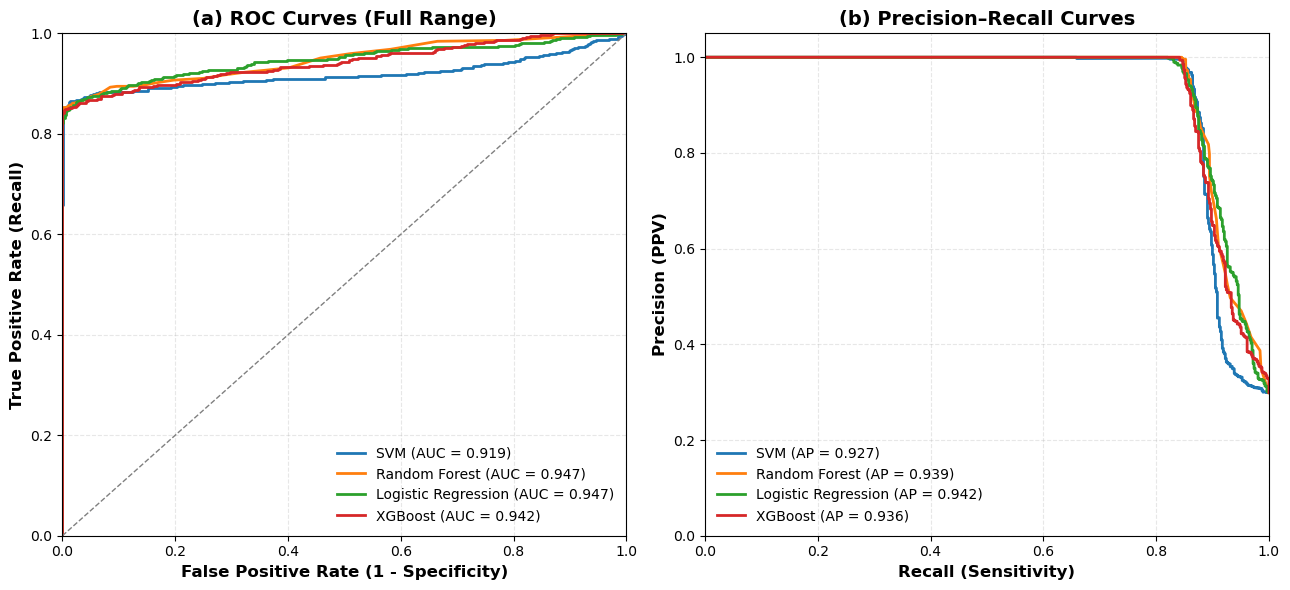

In [12]:
feature_cols = ['AGIS','CIGTS','MD_slope_value','MD','VFI_slope_value','VFI','TDVmean','TDVstd','PDVmean','PDVstd']

models = get_models(seed=0)

X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]
y_train = train_df['Consensus_label']
y_test  = test_df['Consensus_label']

roc_data = []

for name, clf in models:
    clf.fit(X_train, y_train)
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_score = clf.decision_function(X_test)
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    roc_data.append((name.strip(), fpr, tpr, roc_auc))

fig, axes = plt.subplots(1, 2, figsize=(13,6), sharex=True, sharey=False)

# ---------- (a) ROC Curve ----------
ax1 = axes[0]
for name, fpr, tpr, roc_auc in roc_data:
    ax1.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax1.plot([0,1], [0,1], color='gray', linestyle='--', lw=1)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.0])
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, weight='bold')
ax1.set_ylabel('True Positive Rate (Recall)', fontsize=12, weight='bold')
ax1.set_title('(a) ROC Curves (Full Range)', fontsize=14, weight='bold')
ax1.grid(alpha=0.3, linestyle='--')
ax1.legend(loc='lower right', frameon=False, fontsize=10)



# ---------- (b) Precision–Recall Curve ----------
ax2 = axes[1]

for name, clf in models:

    clf.fit(X_train, y_train)

    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_score = clf.decision_function(X_test)
    else:
        continue

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)

    ax2.plot(recall, precision, lw=2,
             label=f'{name} (AP = {ap:.3f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Sensitivity)', fontsize=12, weight='bold')
ax2.set_ylabel('Precision (PPV)', fontsize=12, weight='bold')
ax2.set_title('(b) Precision–Recall Curves', fontsize=14, weight='bold')
ax2.grid(alpha=0.3, linestyle='--')
ax2.legend(loc='lower left', frameon=False, fontsize=10)


plt.tight_layout()
# plt.savefig(image_path / 'ROC_PR_Consensus.tiff')
plt.show()

---
## Table 6

In [13]:
model_names = ['SVM','RF','LR','XGBoost']
table6 = results_df.iloc[len(model_names):].copy()
table6.index = model_names

table6 = table6.rename(columns={'Recall':'Sensitivity',
                                'F1':'F1 score'})

table6

,Accuracy,Sensitivity,Specificity,Precision,F1 score
SVM,0.826,0.660,0.922,0.831,0.736
RF,0.828,0.717,0.892,0.794,0.754
LR,0.811,0.630,0.916,0.814,0.710
XGBoost,0.799,0.681,0.867,0.749,0.714


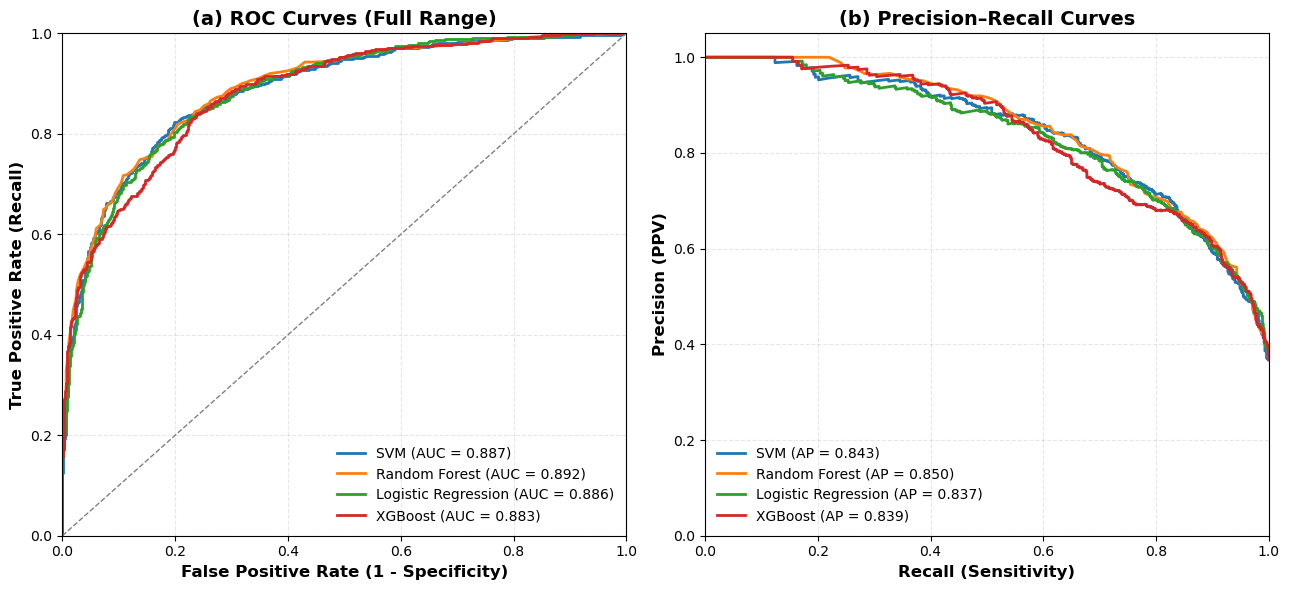

In [14]:
feature_cols = ['AGIS','CIGTS','MD_slope_value','MD','VFI_slope_value','VFI',
                'TDVmean','TDVstd','PDVmean','PDVstd']

models = get_models(seed=0)

roc_data = []

X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]
y_train = train_df['Wiggs_label']
y_test  = test_df['Wiggs_label']

roc_data = []

for name, clf in models:
    clf.fit(X_train, y_train)
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_score = clf.decision_function(X_test)
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    roc_data.append((name.strip(), fpr, tpr, roc_auc))

fig, axes = plt.subplots(1, 2, figsize=(13,6), sharex=True, sharey=False)

# ---------- (a) ROC Curve ----------
ax1 = axes[0]
for name, fpr, tpr, roc_auc in roc_data:
    ax1.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax1.plot([0,1], [0,1], color='gray', linestyle='--', lw=1)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.0])
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, weight='bold')
ax1.set_ylabel('True Positive Rate (Recall)', fontsize=12, weight='bold')
ax1.set_title('(a) ROC Curves (Full Range)', fontsize=14, weight='bold')
ax1.grid(alpha=0.3, linestyle='--')
ax1.legend(loc='lower right', frameon=False, fontsize=10)

# ---------- (b) Precision–Recall Curve ----------
ax2 = axes[1]

for name, clf in models:

    clf.fit(X_train, y_train)

    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_score = clf.decision_function(X_test)
    else:
        continue

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)

    ax2.plot(recall, precision, lw=2,
             label=f'{name} (AP = {ap:.3f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Sensitivity)', fontsize=12, weight='bold')
ax2.set_ylabel('Precision (PPV)', fontsize=12, weight='bold')
ax2.set_title('(b) Precision–Recall Curves', fontsize=14, weight='bold')
ax2.grid(alpha=0.3, linestyle='--')
ax2.legend(loc='lower left', frameon=False, fontsize=10)


plt.tight_layout()
# plt.savefig(image_path / 'ROC_PR_Wiggs.tiff')
plt.show()